In [1]:
import pandas as pd
import pingouin as pg
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore, wilcoxon

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# PARAMS
window_sec = 4

# experimental pre data

## calcium

In [2]:
df_pre = pd.read_csv('df_pre.csv').iloc[:,1:]
df_pre

,Odour,OdourCS,Experiment,Fly ID,file,Time_s,calcium_zscore,TrainingOdour,OdourOnset,TimeFromOdourOnset_s
0,NaN,NaN,pre,057_MDN1-GCaMP7b,/Volumes/ukme23/Projects/Moonwalker_Valence/ra...,0.000000,NaN,OCT,9.0,-9.000000
1,NaN,NaN,pre,057_MDN1-GCaMP7b,/Volumes/ukme23/Projects/Moonwalker_Valence/ra...,0.266329,NaN,OCT,9.0,-8.733671
2,NaN,NaN,pre,057_MDN1-GCaMP7b,/Volumes/ukme23/Projects/Moonwalker_Valence/ra...,0.532659,NaN,OCT,9.0,-8.467341
3,NaN,NaN,pre,057_MDN1-GCaMP7b,/Volumes/ukme23/Projects/Moonwalker_Valence/ra...,0.798988,NaN,OCT,9.0,-8.201012
4,NaN,NaN,pre,057_MDN1-GCaMP7b,/Volumes/ukme23/Projects/Moonwalker_Valence/ra...,1.065317,-0.298281,OCT,9.0,-7.934683
...,...,...,...,...,...,...,...,...,...,...
4329,NaN,NaN,pre,105_MDN1-GCaMP7b,/Volumes/ukme23/Projects/Moonwalker_Valence/ra...,103.602104,1.315789,MCH,94.0,9.602104
4330,NaN,NaN,pre,105_MDN1-GCaMP7b,/Volumes/ukme23/Projects/Moonwalker_Valence/ra...,103.868433,0.413858,MCH,94.0,9.868433
4331,NaN,NaN,pre,105_MDN1-GCaMP7b,/Volumes/ukme23/Projects/Moonwalker_Valence/ra...,104.134763,0.775436,MCH,94.0,10.134763
4332,NaN,NaN,pre,105_MDN1-GCaMP7b,/Volumes/ukme23/Projects/Moonwalker_Valence/ra...,104.401092,1.021630,MCH,94.0,10.401092


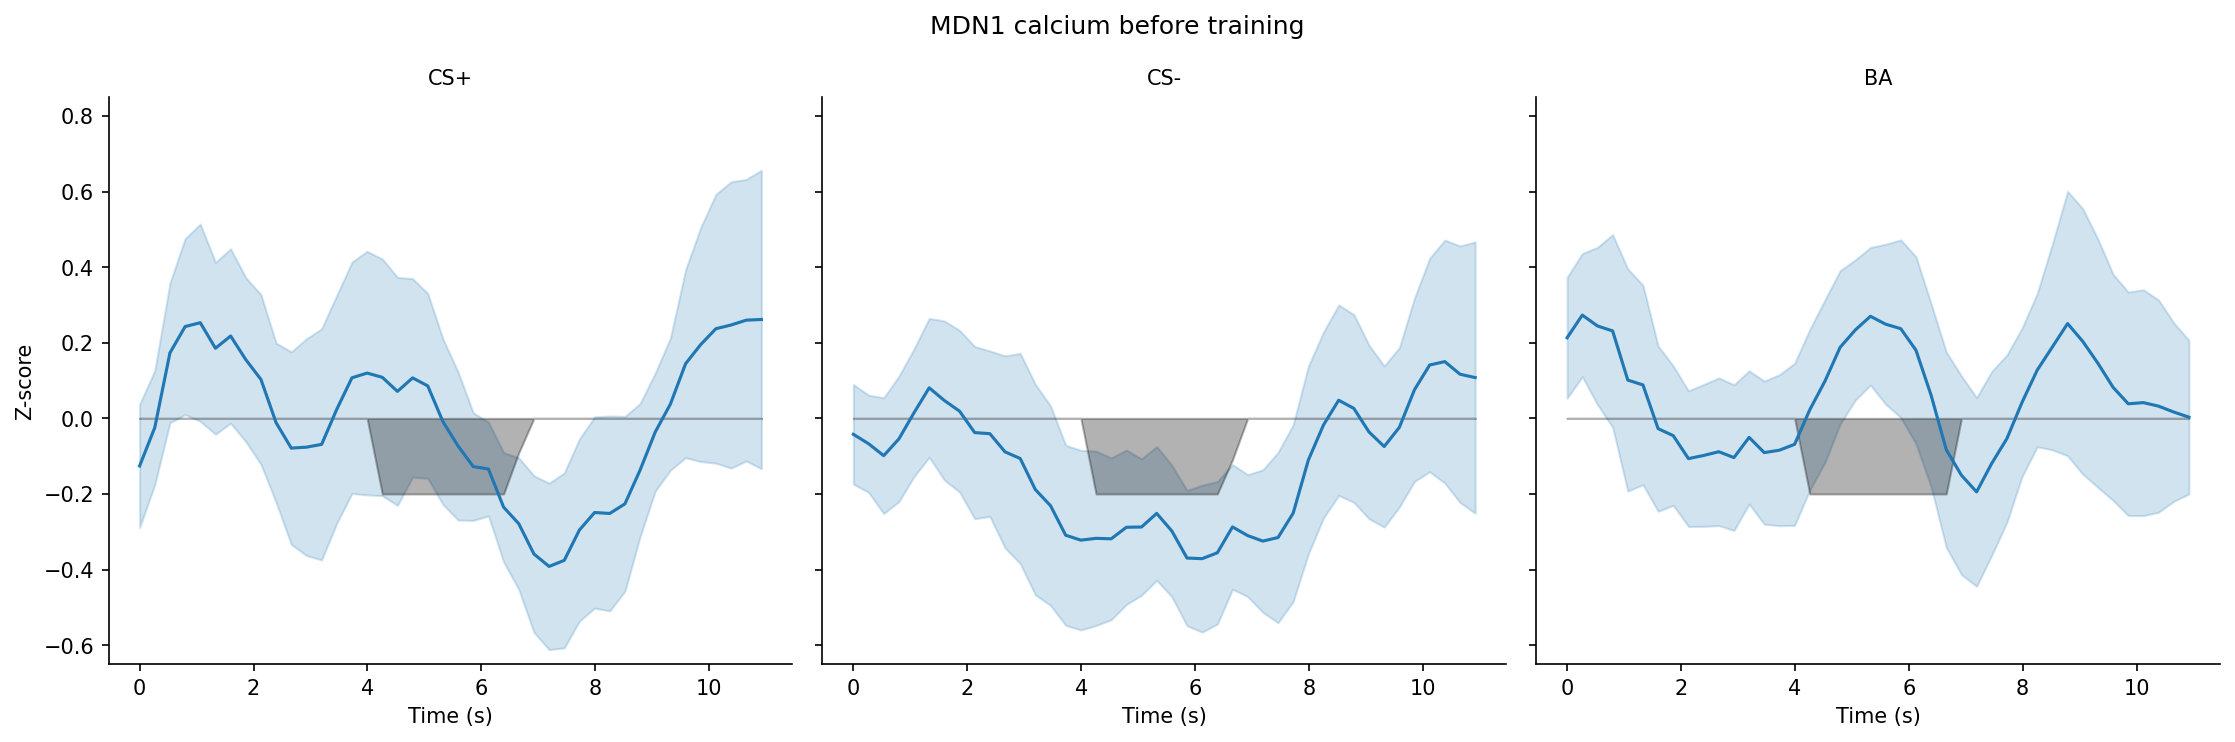

In [3]:
df_pre['OdourCS_trace'] = df_pre['OdourCS'].ffill(limit=int(4*window_sec)).bfill(limit=int(4*window_sec))
df_pre['Odour_trace'] = df_pre['Odour'].notna().astype(float) * -.2

# --- build long-form dataset for CS+ and CS- (mean ± SEM), facetted left/right ---
def _cond_long(df, cond_label, fps=30.038, frame_to_s=8.0):
    traces = []
    odours = []

    for f in df['file'].unique():
        mask = (df['file'] == f) & (df['OdourCS_trace'] == cond_label)
        traces.append(df.loc[mask, 'calcium_zscore'].values)
        odours.append(df.loc[mask, 'Odour_trace'].values)

    wide = pd.DataFrame(traces).T
    wide_odour = pd.DataFrame(odours).T

    long = (wide.reset_index(names='frame')
                .melt(id_vars='frame', var_name='trial', value_name='dff'))

    long['odour'] = wide_odour.reset_index(drop=True).melt()['value']

    long['condition'] = cond_label
    long['time_s'] = long['frame'] / fps * frame_to_s

    long['dff_smooth'] = (
        long.sort_values('frame')
            .groupby('trial')['dff']
            .transform(lambda x: x.rolling(3, center=True, min_periods=1).mean())
    )

    return long

data = pd.concat([
    _cond_long(df_pre, 'CS+'),
    _cond_long(df_pre, 'CS-'),
    _cond_long(df_pre, 'BA'),
], ignore_index=True)

g = sns.relplot(
    data=data,
    x='time_s', y='dff_smooth',
    col='condition',
    kind='line',
    estimator='mean',
    errorbar='se',
    facet_kws=dict(sharex=True, sharey=True),
)

for ax, cond in zip(g.axes.flat, data['condition'].unique()):
    stim = data[data['condition'] == cond].groupby('time_s')['odour'].mean()
    ax.fill_between(stim.index, 0, stim.values, color='black', alpha=0.3)

g.set_axis_labels('Time (s)', 'Z-score')
g.set_titles('{col_name}')
g.set(ylim=(-0.65, 0.85))
plt.suptitle('MDN1 calcium before training')
g.tight_layout()

In [4]:
df_pre.loc[(df_pre.TimeFromOdourOnset_s>-window_sec)&(df_pre.TimeFromOdourOnset_s<0), 'OdourWindow'] = 'pre'
df_pre.loc[(df_pre.TimeFromOdourOnset_s>0)&(df_pre.TimeFromOdourOnset_s<2.5), 'OdourWindow'] = 'stim'

df_pre_agg = df_pre.groupby(['OdourWindow', 'OdourCS_trace', 'Fly ID'])[['calcium_zscore']].mean().reset_index()

df_pre_agg

,OdourWindow,OdourCS_trace,Fly ID,calcium_zscore
0,pre,BA,057_MDN1-GCaMP7b,-0.202235
1,pre,BA,058_MDN1-GCaMP7b,-0.143538
2,pre,BA,062_MDN1-GCaMP7b,0.310214
3,pre,BA,066_MDN1-GCaMP7b,0.926524
4,pre,BA,073_MDN1-GCaMP7b,-0.310182
...,...,...,...,...
61,stim,CS-,098_MDN1-GCaMP7b,0.550384
62,stim,CS-,101_MDN1-GCaMP7b,-0.554768
63,stim,CS-,102_MDN1-GCaMP7b,-0.116180
64,stim,CS-,104_MDN1-GCaMP7b,-1.443341


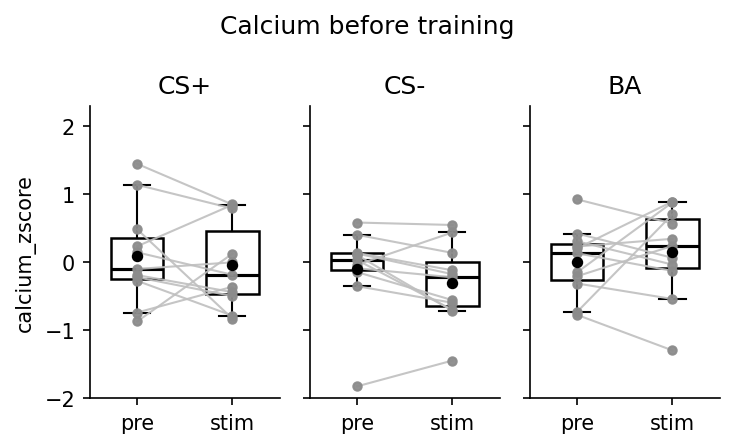

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

conds = ['CS+', 'CS-', 'BA']
vel = 'calcium_zscore'
windows = ['pre', 'stim']

fig, axes = plt.subplots(1, 3, figsize=(5, 3), sharex=True, sharey=True)

for c, cond in enumerate(conds):

    ax = axes[c]

    tmp = df_pre_agg.loc[
        df_pre_agg['OdourCS_trace'] == cond,
        ['Fly ID', 'OdourWindow', vel]
    ].copy()

    wide = (
        tmp.pivot(index='Fly ID', columns='OdourWindow', values=vel)
           .reindex(columns=windows)
    )

    x = np.arange(len(windows))

    # --- boxplots (10th / 90th percentile whiskers) ---
    box_data = [wide[w].dropna().values for w in windows]

    bp = ax.boxplot(
        box_data,
        positions=x,
        widths=0.55,
        whis=(10, 90),
        showfliers=False,
        patch_artist=True,
        boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.2),
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(color='black', linewidth=1.0),
        capprops=dict(color='black', linewidth=1.0),
        zorder=1
    )

    # --- paired grey lines + points on top ---
    for _, row in wide.iterrows():
        yvals = row.values.astype(float)
        mask = ~np.isnan(yvals)

        # paired line across available windows
        if mask.sum() >= 2:
            ax.plot(
                x[mask],
                yvals[mask],
                color='0.75',
                linewidth=1,
                alpha=0.9,
                zorder=3
            )

        # aligned points
        ax.scatter(
            x[mask],
            yvals[mask],
            color='0.55',
            s=16,
            alpha=0.95,
            zorder=4
        )

    # --- optional: median/mean markers on top of boxplots ---
    mean = wide.mean(axis=0)
    sem = wide.sem(axis=0)

    ax.scatter(
        x,
        mean.values,
        color='black',
        s=20,
        zorder=5
    )

    ax.set_xticks(x)
    ax.set_xticklabels(windows)
    ax.set_title(cond)

    if c == 0:
        ax.set_ylabel(vel)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # --- statistics ---
    y_top_data = np.nanmax([np.nanmax(d) if len(d) else np.nan for d in box_data])
    y_bottom_data = np.nanmin([np.nanmin(d) if len(d) else np.nan for d in box_data])
    y_range = y_top_data - y_bottom_data
    h = y_range * 0.10 if y_range > 0 else 0.15

    def p_to_stars(p):
        if p < 0.001:
            return '***'
        elif p < 0.01:
            return '**'
        elif p < 0.05:
            return '*'
        return None

    # pre vs stim
    sub = wide[['pre', 'stim']].dropna()
    if len(sub) > 1:
        stat, p = wilcoxon(sub['pre'], sub['stim'])
        stars = p_to_stars(p)
        if stars is not None:
            y = y_top_data + h * 1.2
            ax.plot([0, 0, 1, 1], [y, y+h*0.25, y+h*0.25, y], color='black', lw=1, zorder=6)
            ax.text(0.5, y+h*0.3, stars, ha='center', va='bottom', fontsize=11, zorder=6)

    ax.set_ylim([-2, 2.3])

fig.suptitle('Calcium before training')
plt.tight_layout()
plt.show()

In [6]:
pg.pairwise_tests(df_pre_agg, between='OdourCS_trace', dv='calcium_zscore', within='OdourWindow', 
                  subject='Fly ID', padjust='holm', parametric=False, within_first=False)#.to_clipboard()

,Contrast,OdourCS_trace,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,OdourCS_trace,-,BA,CS+,False,False,76.0,NaN,two-sided,0.324636,0.649273,holm,0.095592
1,OdourCS_trace,-,BA,CS-,False,False,83.0,NaN,two-sided,0.148562,0.445685,holm,0.515452
2,OdourCS_trace,-,CS+,CS-,False,False,60.0,NaN,two-sided,1.000000,1.000000,holm,0.379433
3,OdourWindow,-,pre,stim,True,False,NaN,23.0,two-sided,0.413086,NaN,NaN,0.189992
4,OdourCS_trace * OdourWindow,BA,pre,stim,True,False,NaN,28.0,two-sided,0.700195,1.000000,holm,-0.245397
5,OdourCS_trace * OdourWindow,CS+,pre,stim,True,False,NaN,26.0,two-sided,0.577148,1.000000,holm,0.200675
6,OdourCS_trace * OdourWindow,CS-,pre,stim,True,False,NaN,16.0,two-sided,0.147461,0.442383,holm,0.340382


## Fly ball

In [7]:
ws_pre = pd.read_csv('ws_pre.csv').iloc[:, 1:]
ws_pre

,Time_s,ForwardVelocity,Odour,OdourCS,Experiment,OdourOnset,TimeFromOdourOnset_s,TrainingOdour,ws_filename,Fly ID
0,0.00,NaN,NaN,NaN,pre,9.0,-9.00,OCT,untitled_new protocol_2025-12-22_001_0011.h5,057_MDN1-GCaMP7b
1,0.01,NaN,NaN,NaN,pre,9.0,-8.99,OCT,untitled_new protocol_2025-12-22_001_0011.h5,057_MDN1-GCaMP7b
2,0.02,NaN,NaN,NaN,pre,9.0,-8.98,OCT,untitled_new protocol_2025-12-22_001_0011.h5,057_MDN1-GCaMP7b
3,0.03,NaN,NaN,NaN,pre,9.0,-8.97,OCT,untitled_new protocol_2025-12-22_001_0011.h5,057_MDN1-GCaMP7b
4,0.04,NaN,NaN,NaN,pre,9.0,-8.96,OCT,untitled_new protocol_2025-12-22_001_0011.h5,057_MDN1-GCaMP7b
...,...,...,...,...,...,...,...,...,...,...
115484,104.94,0.003799,NaN,NaN,pre,94.0,10.94,MCH,untitled-wv_2026-01-12_001_0017.h5,105_MDN1-GCaMP7b
115485,104.95,0.003800,NaN,NaN,pre,94.0,10.95,MCH,untitled-wv_2026-01-12_001_0017.h5,105_MDN1-GCaMP7b
115486,104.96,0.003801,NaN,NaN,pre,94.0,10.96,MCH,untitled-wv_2026-01-12_001_0017.h5,105_MDN1-GCaMP7b
115487,104.97,0.003801,NaN,NaN,pre,94.0,10.97,MCH,untitled-wv_2026-01-12_001_0017.h5,105_MDN1-GCaMP7b


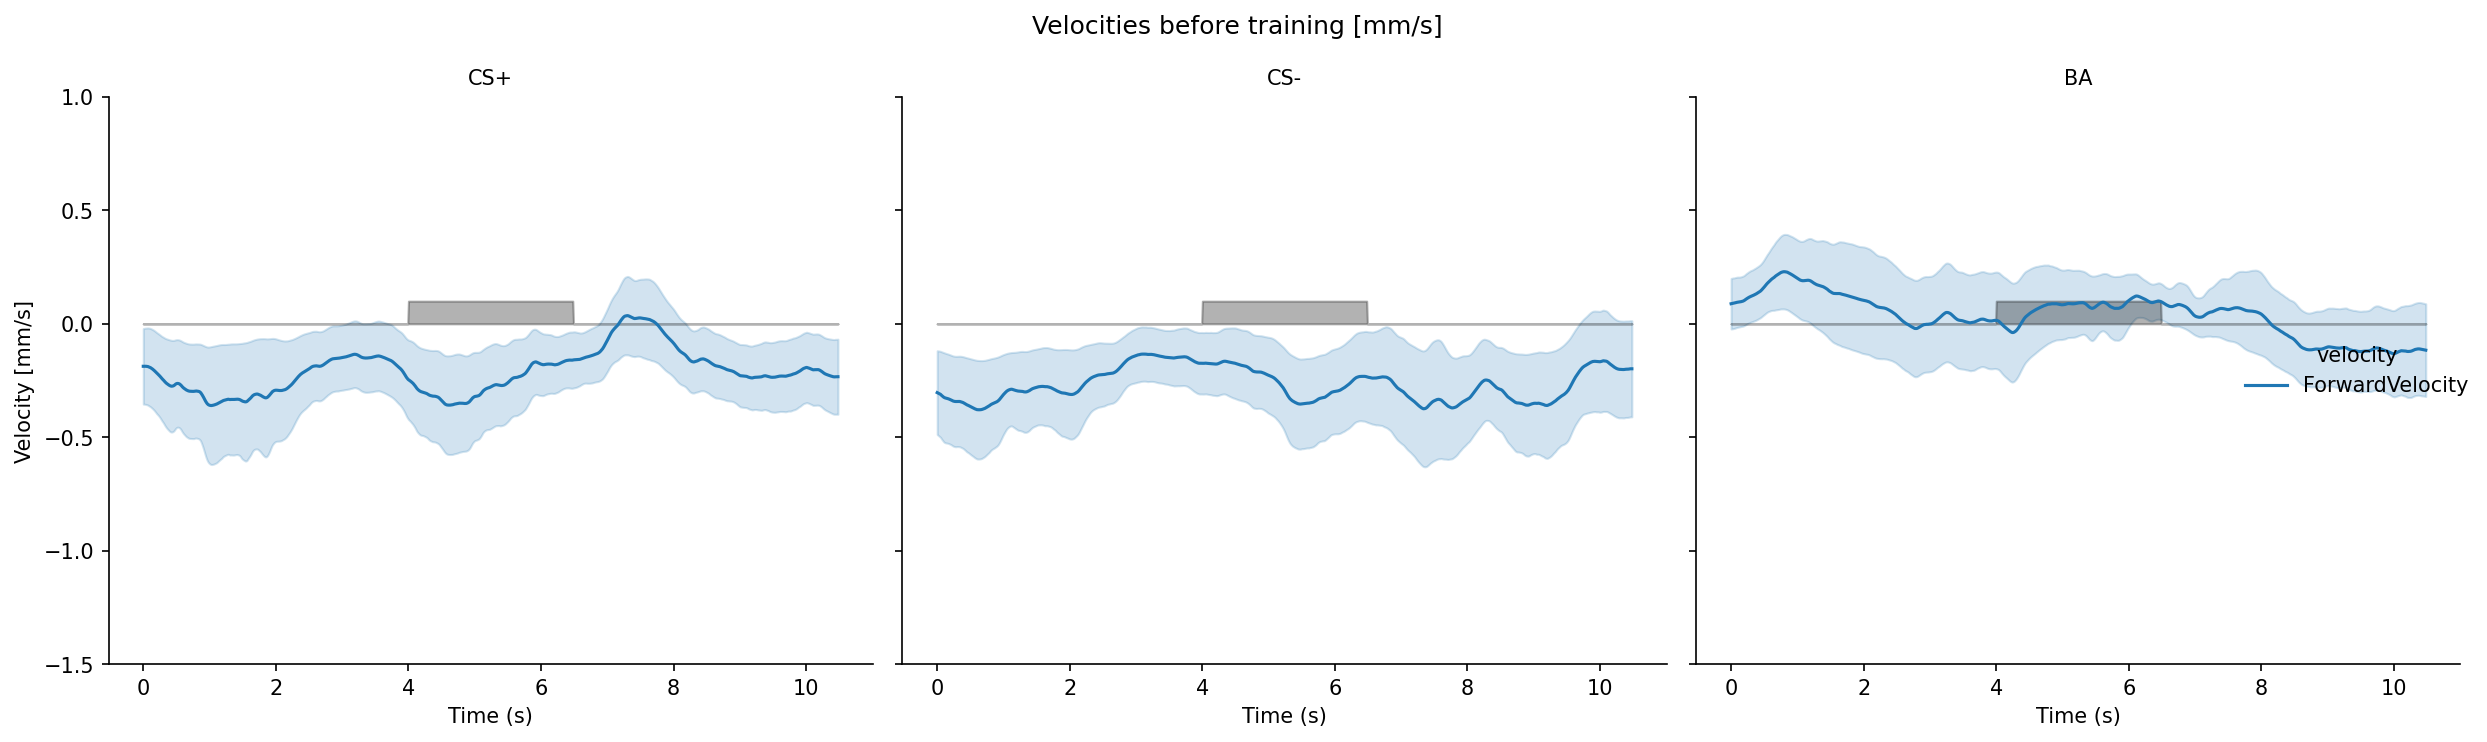

In [8]:
ws_pre['OdourCS_trace'] = ws_pre['OdourCS'].ffill(limit=100*window_sec).bfill(limit=100*window_sec)  # forward-fill odour labels
ws_pre['Odour_trace'] = ws_pre['Odour'].notna().astype(float)*0.1

# --- build long-form dataset for CS+ and CS- (mean ± SEM), facetted left/right ---
def _cond_long(df, cond_label, fps=100, frame_to_s=1.0):

    rows = []

    for f in df['ws_filename'].unique():

        mask = (df['ws_filename'] == f) & (df['OdourCS_trace'] == cond_label)
        sub = df.loc[mask]

        tmp = pd.DataFrame({
            'frame': range(len(sub)),
            'ForwardVelocity': sub['ForwardVelocity'].values,
            'odour': sub['Odour_trace'].values,
            'trial': f
        })

        rows.append(tmp)

    wide = pd.concat(rows, ignore_index=True)

    wide['time_s'] = wide['frame'] / fps * frame_to_s
    wide['condition'] = cond_label

    # reshape velocities to long format
    long = wide.melt(
        id_vars=['frame','trial','time_s','condition','odour'],
        value_vars=['ForwardVelocity'],
        var_name='velocity',
        value_name='value'
    )

    long['value_smooth'] = (
        long.sort_values('frame')
            .groupby(['trial','velocity'])['value']
            .transform(lambda x: x.rolling(10, center=True, min_periods=1).mean())
    )

    return long

data = pd.concat([
    _cond_long(ws_pre, 'CS+'),
    _cond_long(ws_pre, 'CS-'),
    _cond_long(ws_pre, 'BA'),
], ignore_index=True)

g = sns.relplot(
    data=data,
    x='time_s',
    y='value_smooth',
    hue='velocity',
    col='condition',
    kind='line',
    estimator='mean',
    errorbar='se',
    facet_kws=dict(sharex=True, sharey=True),
)

for ax, cond in zip(g.axes.flat, data['condition'].unique()):
    stim = data[data['condition'] == cond].groupby('time_s')['odour'].mean()
    ax.fill_between(stim.index, 0, stim.values, color='black', alpha=0.3)

g.set_axis_labels('Time (s)', 'Velocity [mm/s]')
g.set_titles('{col_name}')
g.set(ylim=(-1.5,1))
plt.suptitle('Velocities before training [mm/s]')
plt.tight_layout()


In [9]:
ws_pre['OdourWindow'] = pd.NA
ws_pre.loc[(ws_pre.TimeFromOdourOnset_s>-window_sec)&(ws_pre.TimeFromOdourOnset_s<0), 'OdourWindow'] = 'pre'
ws_pre.loc[(ws_pre.TimeFromOdourOnset_s>0)&(ws_pre.TimeFromOdourOnset_s<2.5), 'OdourWindow'] = 'stim'

ws_pre_agg = ws_pre.groupby(['OdourWindow', 'OdourCS_trace', 'Fly ID'])['ForwardVelocity'].mean().reset_index()
ws_pre_agg

,OdourWindow,OdourCS_trace,Fly ID,ForwardVelocity
0,pre,BA,057_MDN1-GCaMP7b,0.525562
1,pre,BA,058_MDN1-GCaMP7b,-1.118202
2,pre,BA,062_MDN1-GCaMP7b,0.003860
3,pre,BA,066_MDN1-GCaMP7b,1.269388
4,pre,BA,073_MDN1-GCaMP7b,0.119221
...,...,...,...,...
61,stim,CS-,098_MDN1-GCaMP7b,-1.208046
62,stim,CS-,101_MDN1-GCaMP7b,0.003898
63,stim,CS-,102_MDN1-GCaMP7b,0.003890
64,stim,CS-,104_MDN1-GCaMP7b,0.003879


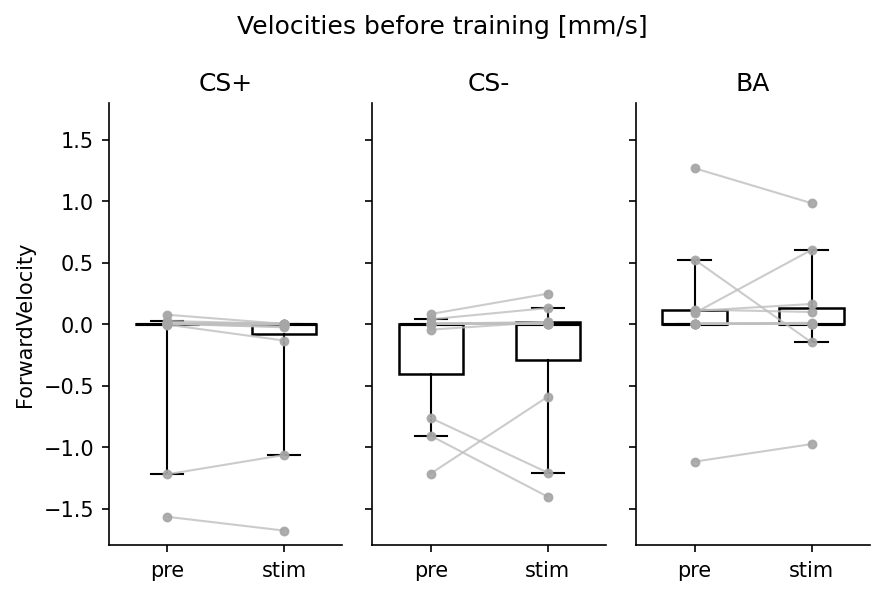

In [10]:
conds = ['CS+', 'CS-', 'BA']
vels = ['ForwardVelocity']
windows = ['pre', 'stim']

fig, axes = plt.subplots(1, 3, figsize=(6, 4), sharex=True, sharey='row')

def p_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    return None

for r, vel in enumerate(vels):
    for c, cond in enumerate(conds):

        ax = axes[c]

        tmp = ws_pre_agg.loc[
            ws_pre_agg['OdourCS_trace'] == cond,
            ['Fly ID', 'OdourWindow', vel]
        ].copy()

        wide = (
            tmp.pivot(index='Fly ID', columns='OdourWindow', values=vel)
               .reindex(columns=windows)
        )

        x = np.arange(len(windows))

        # --- 10/90 percentile boxplots ---
        box_data = [wide[w].dropna().values for w in windows]

        ax.boxplot(
            box_data,
            positions=x,
            widths=0.55,
            whis=(10, 90),
            showfliers=False,
            patch_artist=True,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.2),
            medianprops=dict(color='black', linewidth=1.5),
            whiskerprops=dict(color='black', linewidth=1.0),
            capprops=dict(color='black', linewidth=1.0),
            zorder=1
        )

        # --- individual paired traces on top ---
        for _, row in wide.iterrows():
            yvals = row.values.astype(float)
            mask = ~np.isnan(yvals)

            if mask.sum() >= 2:
                ax.plot(
                    x[mask], yvals[mask],
                    color='0.75',
                    linewidth=1,
                    alpha=0.8,
                    zorder=3
                )

            ax.scatter(
                x[mask], yvals[mask],
                color='0.65',
                s=14,
                alpha=0.9,
                zorder=4
            )

        ax.set_xticks(x)
        ax.set_xticklabels(windows)
        # ax.set_yscale('symlog', linthresh=0.01)
        ax.set_ylim([-1.8, 1.8])

        if r == 0:
            ax.set_title(cond)

        if c == 0:
            ax.set_ylabel(vel)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # --- statistics ---
        finite_vals = np.concatenate([d for d in box_data if len(d) > 0]) if any(len(d) > 0 for d in box_data) else np.array([0])
        y_max = np.nanmax(finite_vals)
        y_min = np.nanmin(finite_vals)
        y_range = y_max - y_min
        h = y_range * 0.12 if y_range > 0 else 0.1

        # pre vs stim
        sub = wide[['pre', 'stim']].dropna()
        if len(sub) > 1:
            statistic, p = wilcoxon(sub['pre'], sub['stim'])
            stars = p_to_stars(p)
            if stars is not None:
                y = y_max + h
                ax.plot([0, 0, 1, 1], [y, y+h*0.2, y+h*0.2, y], color='black', lw=1, zorder=5)
                ax.text(0.5, y+h*0.25, stars, ha='center', va='bottom', fontsize=14, zorder=6)

fig.suptitle('Velocities before training [mm/s]')
plt.tight_layout()
plt.show()

In [11]:
pg.normality(ws_pre_agg['ForwardVelocity'])

,W,pval,normal
ForwardVelocity,0.742218,1.957446e-09,False


In [12]:
pg.pairwise_tests(ws_pre_agg, between='OdourCS_trace', dv='ForwardVelocity', within='OdourWindow', 
                  subject='Fly ID', padjust='holm', parametric=False, within_first=False)#.to_clipboard()

,Contrast,OdourCS_trace,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,OdourCS_trace,-,BA,CS+,False,False,92.0,NaN,two-sided,0.041789,0.125367,holm,0.599652
1,OdourCS_trace,-,BA,CS-,False,False,83.0,NaN,two-sided,0.148562,0.297124,holm,0.644935
2,OdourCS_trace,-,CS+,CS-,False,False,52.0,NaN,two-sided,0.599361,0.599361,holm,-0.000716
3,OdourWindow,-,pre,stim,True,False,NaN,24.0,two-sided,0.464844,NaN,NaN,0.029952
4,OdourCS_trace * OdourWindow,BA,pre,stim,True,False,NaN,30.0,two-sided,0.831055,1.000000,holm,0.043240
5,OdourCS_trace * OdourWindow,CS+,pre,stim,True,False,NaN,11.0,two-sided,0.053711,0.161133,holm,0.035755
6,OdourCS_trace * OdourWindow,CS-,pre,stim,True,False,NaN,29.0,two-sided,0.764648,1.000000,holm,-0.003117


# experimental test data

## calcium

In [13]:
df_test = pd.read_csv('df_test.csv').iloc[:, 1:]
df_test

,Odour,OdourCS,Experiment,Fly ID,trial,file,Time_s,calcium_zscore,TrainingOdour,OdourOnset,TimeFromOdourOnset_s,CSplusFirst,OdourCS_trace,trial_to_keep
0,NaN,NaN,test,057_MDN1-GCaMP7b,1,/Volumes/ukme23/Projects/Moonwalker_Valence/ra...,0.000000,NaN,OCT,9.0,-9.000000,False,NaN,1
1,NaN,NaN,test,057_MDN1-GCaMP7b,1,/Volumes/ukme23/Projects/Moonwalker_Valence/ra...,0.266329,NaN,OCT,9.0,-8.733671,False,NaN,1
2,NaN,NaN,test,057_MDN1-GCaMP7b,1,/Volumes/ukme23/Projects/Moonwalker_Valence/ra...,0.532659,NaN,OCT,9.0,-8.467341,False,NaN,1
3,NaN,NaN,test,057_MDN1-GCaMP7b,1,/Volumes/ukme23/Projects/Moonwalker_Valence/ra...,0.798988,NaN,OCT,9.0,-8.201012,False,NaN,1
4,NaN,NaN,test,057_MDN1-GCaMP7b,1,/Volumes/ukme23/Projects/Moonwalker_Valence/ra...,1.065317,0.857424,OCT,9.0,-7.934683,False,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4329,NaN,NaN,test,105_MDN1-GCaMP7b,1,/Volumes/ukme23/Projects/Moonwalker_Valence/ra...,103.602104,-0.580327,MCH,94.0,9.602104,False,NaN,1
4330,NaN,NaN,test,105_MDN1-GCaMP7b,1,/Volumes/ukme23/Projects/Moonwalker_Valence/ra...,103.868433,-0.926346,MCH,94.0,9.868433,False,NaN,1
4331,NaN,NaN,test,105_MDN1-GCaMP7b,1,/Volumes/ukme23/Projects/Moonwalker_Valence/ra...,104.134763,0.576046,MCH,94.0,10.134763,False,NaN,1
4332,NaN,NaN,test,105_MDN1-GCaMP7b,1,/Volumes/ukme23/Projects/Moonwalker_Valence/ra...,104.401092,-0.206844,MCH,94.0,10.401092,False,NaN,1


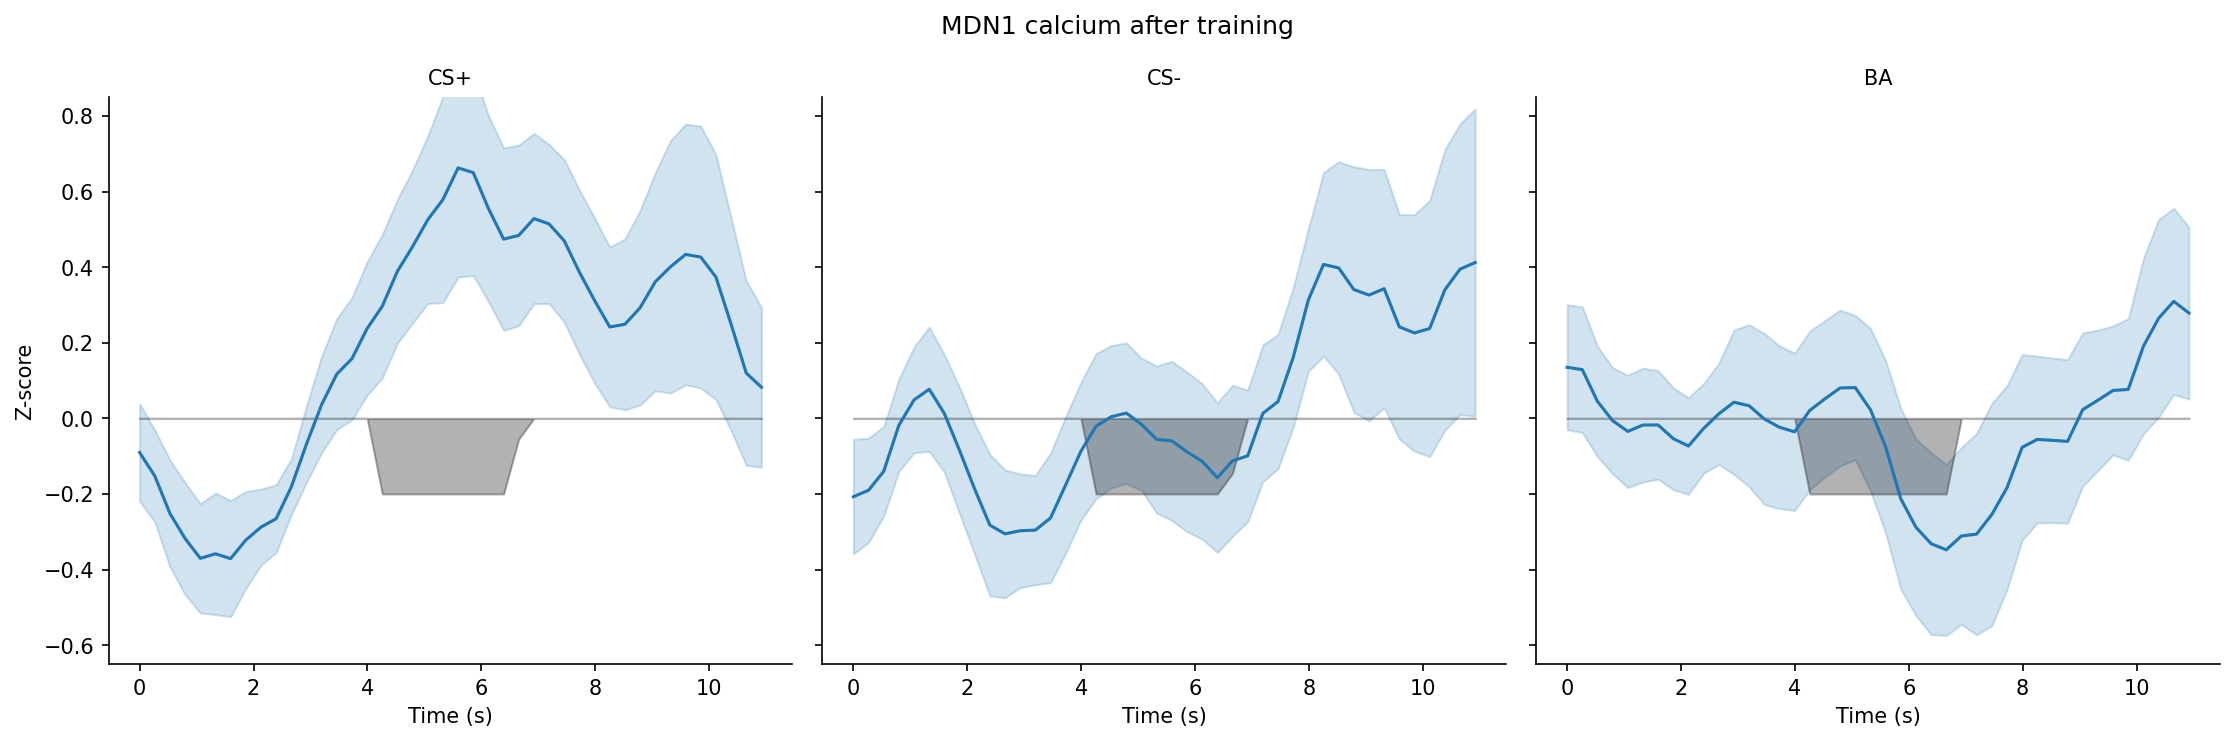

In [14]:
df_test['OdourCS_trace'] = df_test['OdourCS'].ffill(limit=4*window_sec).bfill(limit=4*window_sec)  # limit=94
df_test['Odour_trace'] = df_test['Odour'].notna().astype(float) * -.2

# --- build long-form dataset for CS+ and CS- (mean ± SEM), facetted left/right ---
def _cond_long(df, cond_label, fps=30.038, frame_to_s=8.0):
    traces = []
    odours = []

    for f in df['file'].unique():
        mask = (df['file'] == f) & (df['OdourCS_trace'] == cond_label)
        traces.append(df.loc[mask, 'calcium_zscore'].values)
        odours.append(df.loc[mask, 'Odour_trace'].values)

    wide = pd.DataFrame(traces).T
    wide_odour = pd.DataFrame(odours).T

    long = (wide.reset_index(names='frame')
                .melt(id_vars='frame', var_name='trial', value_name='dff'))

    long['odour'] = wide_odour.reset_index(drop=True).melt()['value']

    long['condition'] = cond_label
    long['time_s'] = long['frame'] / fps * frame_to_s

    long['dff_smooth'] = (
        long.sort_values('frame')
            .groupby('trial')['dff']
            .transform(lambda x: x.rolling(3, center=True, min_periods=1).mean())
    )

    return long

data = pd.concat([
    _cond_long(df_test, 'CS+'),
    _cond_long(df_test, 'CS-'),
    _cond_long(df_test, 'BA'),
], ignore_index=True)

g = sns.relplot(
    data=data,
    x='time_s', y='dff_smooth',
    col='condition',
    kind='line',
    estimator='mean',
    errorbar='se',
    facet_kws=dict(sharex=True, sharey=True),
)

for ax, cond in zip(g.axes.flat, data['condition'].unique()):
    stim = data[data['condition'] == cond].groupby('time_s')['odour'].mean()
    ax.fill_between(stim.index, 0, stim.values, color='black', alpha=0.3)

g.set_axis_labels('Time (s)', 'Z-score')
g.set_titles('{col_name}')
g.set(ylim=(-0.65, 0.85))
plt.suptitle('MDN1 calcium after training')
g.tight_layout()

In [15]:
df_test['OdourWindow'] = pd.NA
df_test.loc[(df_test.TimeFromOdourOnset_s>-window_sec)&(df_test.TimeFromOdourOnset_s<0), 'OdourWindow'] = 'pre'
df_test.loc[(df_test.TimeFromOdourOnset_s>0)&(df_test.TimeFromOdourOnset_s<2.5), 'OdourWindow'] = 'stim'

df_test_agg = df_test.groupby(['OdourWindow', 'OdourCS_trace', 'Fly ID'])['calcium_zscore'].mean().reset_index()

df_test_agg

,OdourWindow,OdourCS_trace,Fly ID,calcium_zscore
0,pre,BA,057_MDN1-GCaMP7b,-0.801203
1,pre,BA,058_MDN1-GCaMP7b,0.180116
2,pre,BA,062_MDN1-GCaMP7b,0.028168
3,pre,BA,066_MDN1-GCaMP7b,-0.205375
4,pre,BA,073_MDN1-GCaMP7b,0.342359
...,...,...,...,...
61,stim,CS-,098_MDN1-GCaMP7b,0.298539
62,stim,CS-,101_MDN1-GCaMP7b,0.434756
63,stim,CS-,102_MDN1-GCaMP7b,0.508565
64,stim,CS-,104_MDN1-GCaMP7b,0.308123


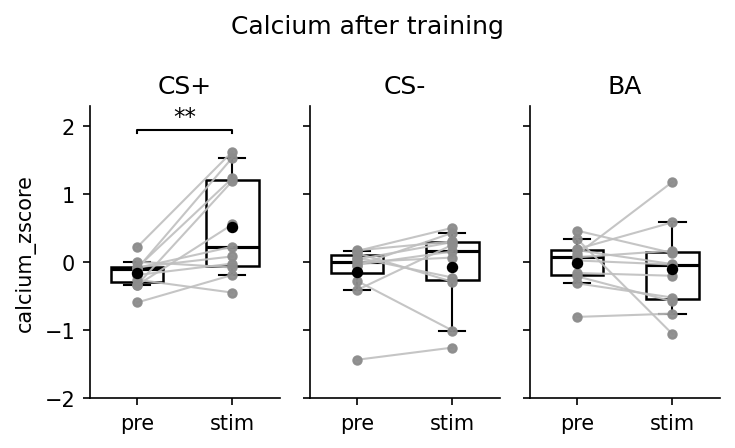

In [16]:
conds = ['CS+', 'CS-', 'BA']
vel = 'calcium_zscore'
windows = ['pre', 'stim']

fig, axes = plt.subplots(1, 3, figsize=(5, 3), sharex=True, sharey=True)

for c, cond in enumerate(conds):

    ax = axes[c]

    tmp = df_test_agg.loc[
        df_test_agg['OdourCS_trace'] == cond,
        ['Fly ID', 'OdourWindow', vel]
    ].copy()

    wide = (
        tmp.pivot(index='Fly ID', columns='OdourWindow', values=vel)
           .reindex(columns=windows)
    )

    x = np.arange(len(windows))

    # --- boxplots (10th / 90th percentile whiskers) ---
    box_data = [wide[w].dropna().values for w in windows]

    bp = ax.boxplot(
        box_data,
        positions=x,
        widths=0.55,
        whis=(10, 90),
        showfliers=False,
        patch_artist=True,
        boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.2),
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(color='black', linewidth=1.0),
        capprops=dict(color='black', linewidth=1.0),
        zorder=1
    )

    # --- paired grey lines + points on top ---
    for _, row in wide.iterrows():
        yvals = row.values.astype(float)
        mask = ~np.isnan(yvals)

        # paired line across available windows
        if mask.sum() >= 2:
            ax.plot(
                x[mask],
                yvals[mask],
                color='0.75',
                linewidth=1,
                alpha=0.9,
                zorder=3
            )

        # aligned points
        ax.scatter(
            x[mask],
            yvals[mask],
            color='0.55',
            s=16,
            alpha=0.95,
            zorder=4
        )

    # --- optional: median/mean markers on top of boxplots ---
    mean = wide.mean(axis=0)
    sem = wide.sem(axis=0)

    ax.scatter(
        x,
        mean.values,
        color='black',
        s=20,
        zorder=5
    )

    ax.set_xticks(x)
    ax.set_xticklabels(windows)
    ax.set_title(cond)

    if c == 0:
        ax.set_ylabel(vel)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # --- statistics ---
    y_top_data = np.nanmax([np.nanmax(d) if len(d) else np.nan for d in box_data])
    y_bottom_data = np.nanmin([np.nanmin(d) if len(d) else np.nan for d in box_data])
    y_range = y_top_data - y_bottom_data
    h = y_range * 0.10 if y_range > 0 else 0.15

    def p_to_stars(p):
        if p < 0.001:
            return '***'
        elif p < 0.01:
            return '**'
        elif p < 0.05:
            return '*'
        return None

    # pre vs stim
    sub = wide[['pre', 'stim']].dropna()
    if len(sub) > 1:
        stat, p = wilcoxon(sub['pre'], sub['stim'])
        stars = p_to_stars(p)
        if stars is not None:
            y = y_top_data + h * 1.2
            ax.plot([0, 0, 1, 1], [y, y+h*0.25, y+h*0.25, y], color='black', lw=1, zorder=6)
            ax.text(0.5, y+h*0.3, stars, ha='center', va='bottom', fontsize=11, zorder=6)

    ax.set_ylim([-2, 2.3])

fig.suptitle('Calcium after training')
plt.tight_layout()
plt.show()

In [17]:
pg.normality(df_test_agg.calcium_zscore)

,W,pval,normal
calcium_zscore,0.93404,0.001676,False


In [18]:
pg.pairwise_tests(df_test_agg, between='OdourCS_trace', dv='calcium_zscore', within='OdourWindow', 
                  subject='Fly ID', padjust='holm', parametric=False, within_first=False)#.to_clipboard()

,Contrast,OdourCS_trace,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,OdourCS_trace,-,BA,CS+,False,False,43.0,NaN,two-sided,0.264292,0.792875,holm,-0.526624
1,OdourCS_trace,-,BA,CS-,False,False,60.0,NaN,two-sided,1.000000,1.000000,holm,0.114825
2,OdourCS_trace,-,CS+,CS-,False,False,74.0,NaN,two-sided,0.393302,0.792875,holm,0.600918
3,OdourWindow,-,pre,stim,True,False,NaN,10.0,two-sided,0.041992,NaN,NaN,-0.716848
4,OdourCS_trace * OdourWindow,BA,pre,stim,True,False,NaN,25.0,two-sided,0.519531,1.000000,holm,0.171851
5,OdourCS_trace * OdourWindow,CS+,pre,stim,True,False,NaN,5.0,two-sided,0.009766,0.029297,holm,-1.199777
6,OdourCS_trace * OdourWindow,CS-,pre,stim,True,False,NaN,25.0,two-sided,0.519531,1.000000,holm,-0.145048


## Fly ball

In [19]:
ws_test = pd.read_csv('ws_test.csv').iloc[:, 1:]
ws_test

,Time_s,ForwardVelocity,Odour,OdourCS,Experiment,OdourOnset,TimeFromOdourOnset_s,TrainingOdour,ws_filename,Fly ID
0,0.00,NaN,NaN,NaN,test,9.0,-9.00,OCT,untitled_new protocol_2025-12-22_001_0013.h5,057_MDN1-GCaMP7b
1,0.01,NaN,NaN,NaN,test,9.0,-8.99,OCT,untitled_new protocol_2025-12-22_001_0013.h5,057_MDN1-GCaMP7b
2,0.02,NaN,NaN,NaN,test,9.0,-8.98,OCT,untitled_new protocol_2025-12-22_001_0013.h5,057_MDN1-GCaMP7b
3,0.03,NaN,NaN,NaN,test,9.0,-8.97,OCT,untitled_new protocol_2025-12-22_001_0013.h5,057_MDN1-GCaMP7b
4,0.04,NaN,NaN,NaN,test,9.0,-8.96,OCT,untitled_new protocol_2025-12-22_001_0013.h5,057_MDN1-GCaMP7b
...,...,...,...,...,...,...,...,...,...,...
115484,104.94,0.003744,NaN,NaN,test,94.0,10.94,MCH,untitled-wv_2026-01-12_001_0019.h5,105_MDN1-GCaMP7b
115485,104.95,0.003743,NaN,NaN,test,94.0,10.95,MCH,untitled-wv_2026-01-12_001_0019.h5,105_MDN1-GCaMP7b
115486,104.96,0.003744,NaN,NaN,test,94.0,10.96,MCH,untitled-wv_2026-01-12_001_0019.h5,105_MDN1-GCaMP7b
115487,104.97,0.003744,NaN,NaN,test,94.0,10.97,MCH,untitled-wv_2026-01-12_001_0019.h5,105_MDN1-GCaMP7b


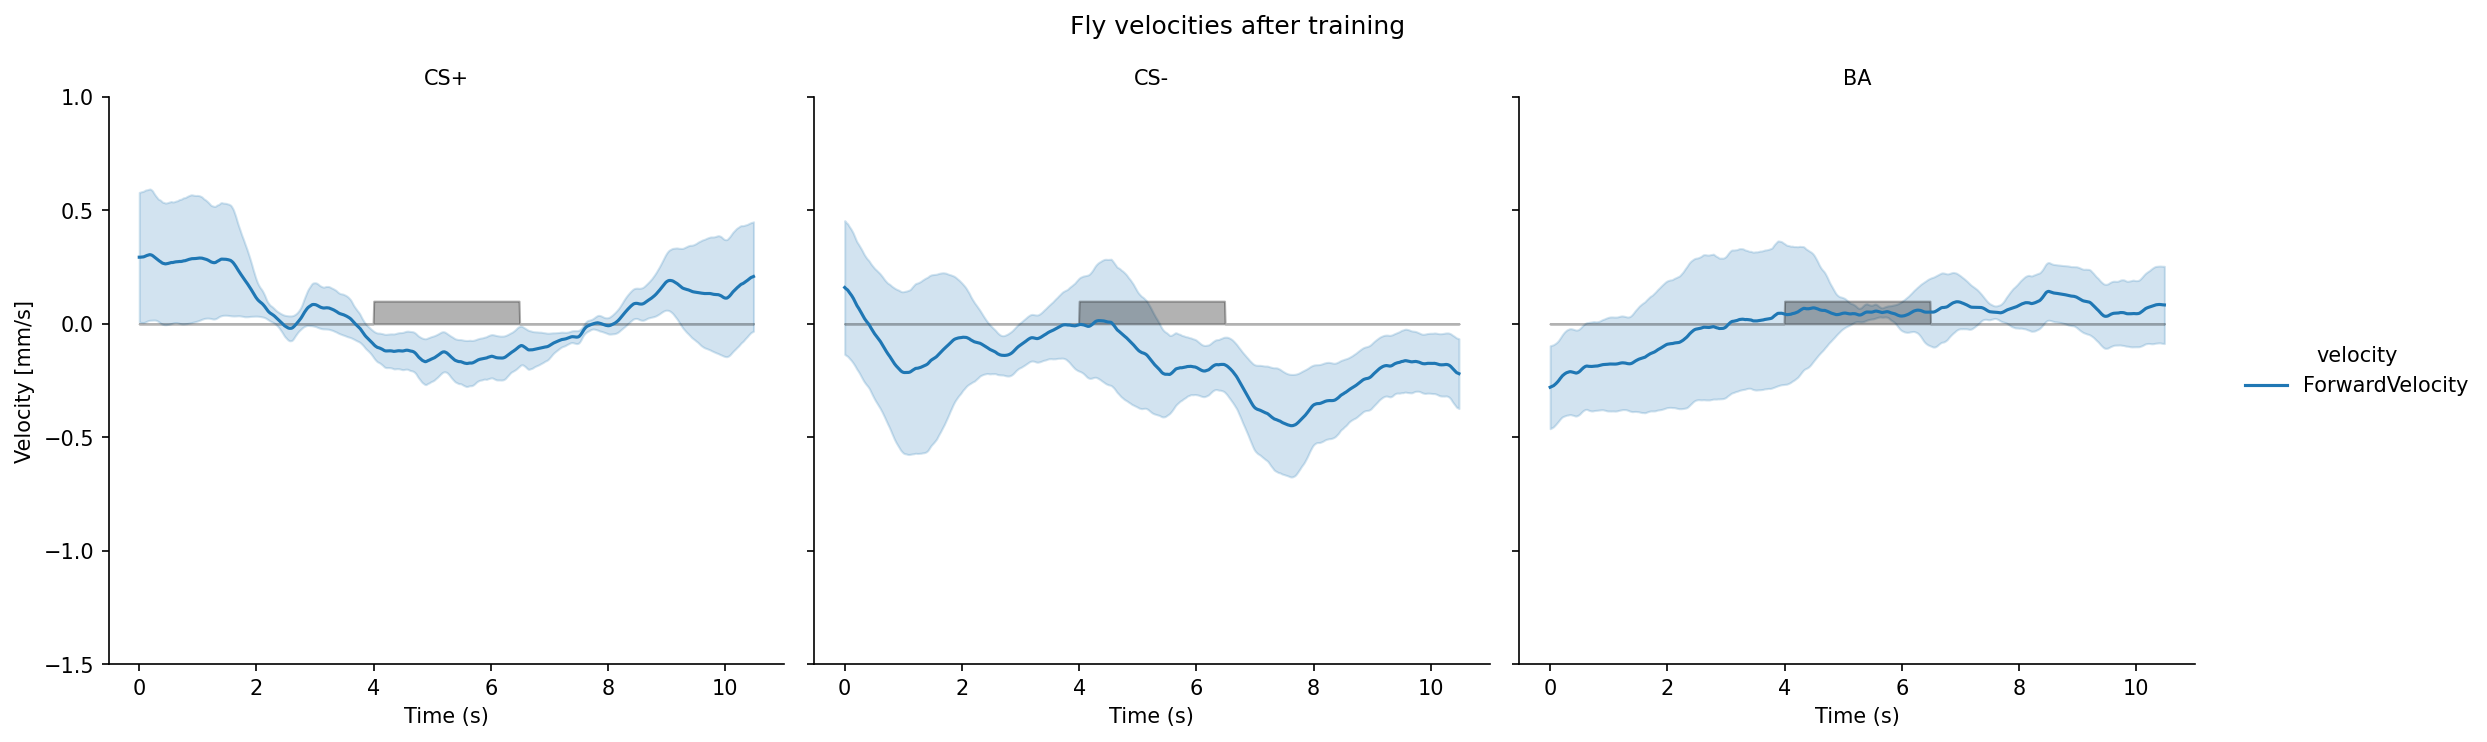

In [ ]:
ws_test['OdourCS_trace'] = ws_test['OdourCS'].ffill(limit=100*window_sec).bfill(limit=100*window_sec)  # forward-fill odour labels for the first 22s (2200 frames at 100Hz)
ws_test['Odour_trace'] = ws_test['Odour'].notna().astype(float)*0.1

# --- build long-form dataset for CS+ and CS- (mean ± SEM), facetted left/right ---
def _cond_long(df, cond_label, fps=100, frame_to_s=1.0):

    rows = []

    for f in df['ws_filename'].unique():

        mask = (df['ws_filename'] == f) & (df['OdourCS_trace'] == cond_label)
        sub = df.loc[mask]

        tmp = pd.DataFrame({
            'frame': range(len(sub)),
            'ForwardVelocity': sub['ForwardVelocity'].values,
            'odour': sub['Odour_trace'].values,
            'trial': f
        })

        rows.append(tmp)

    wide = pd.concat(rows, ignore_index=True)

    wide['time_s'] = wide['frame'] / fps * frame_to_s
    wide['condition'] = cond_label

    # reshape velocities to long format
    long = wide.melt(
        id_vars=['frame','trial','time_s','condition','odour'],
        value_vars=['ForwardVelocity'],
        var_name='velocity',
        value_name='value'
    )

    long['value_smooth'] = (
        long.sort_values('frame')
            .groupby(['trial','velocity'])['value']
            .transform(lambda x: x.rolling(10, center=True, min_periods=1).mean())
    )

    return long

data = pd.concat([
    _cond_long(ws_test, 'CS+'),
    _cond_long(ws_test, 'CS-'),
    _cond_long(ws_test, 'BA'),
], ignore_index=True)

g = sns.relplot(
    data=data,
    x='time_s',
    y='value_smooth',
    hue='velocity',
    col='condition',
    kind='line',
    estimator='mean',
    errorbar='se',
    facet_kws=dict(sharex=True, sharey=True),
)

for ax, cond in zip(g.axes.flat, data['condition'].unique()):
    stim = data[data['condition'] == cond].groupby('time_s')['odour'].mean()
    ax.fill_between(stim.index, 0, stim.values, color='black', alpha=0.3)

g.set_axis_labels('Time (s)', 'Velocity [mm/s]')
g.set_titles('{col_name}')
g.set(ylim=(-1.5,1))

plt.suptitle('Fly velocities after training')
g.tight_layout()

In [21]:
ws_test['OdourWindow'] = pd.NA
ws_test.loc[(ws_test.TimeFromOdourOnset_s>-window_sec)&(ws_test.TimeFromOdourOnset_s<0), 'OdourWindow'] = 'pre'
ws_test.loc[(ws_test.TimeFromOdourOnset_s>0)&(ws_test.TimeFromOdourOnset_s<2.5), 'OdourWindow'] = 'stim'

odour_test_agg = ws_test.groupby(['OdourWindow', 'OdourCS_trace', 'Fly ID'])[['ForwardVelocity']].mean().reset_index()
odour_test_agg

,OdourWindow,OdourCS_trace,Fly ID,ForwardVelocity
0,pre,BA,057_MDN1-GCaMP7b,1.217161
1,pre,BA,058_MDN1-GCaMP7b,-1.591799
2,pre,BA,062_MDN1-GCaMP7b,0.003851
3,pre,BA,066_MDN1-GCaMP7b,0.051790
4,pre,BA,073_MDN1-GCaMP7b,0.227309
...,...,...,...,...
61,stim,CS-,098_MDN1-GCaMP7b,-0.132627
62,stim,CS-,101_MDN1-GCaMP7b,0.003874
63,stim,CS-,102_MDN1-GCaMP7b,0.003878
64,stim,CS-,104_MDN1-GCaMP7b,0.003793


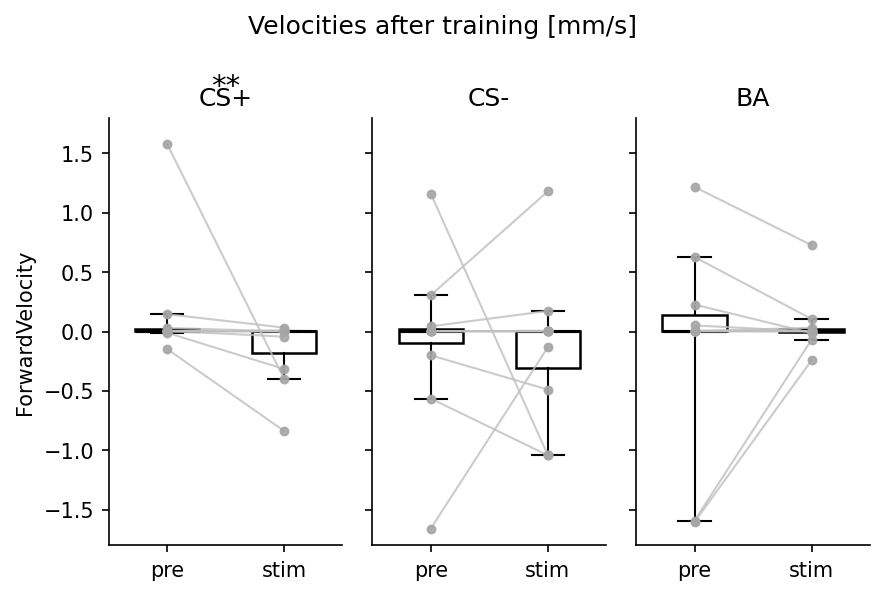

In [ ]:
conds = ['CS+', 'CS-', 'BA']
vels = ['ForwardVelocity']
windows = ['pre', 'stim']

fig, axes = plt.subplots(1, 3, figsize=(6, 4), sharex=True, sharey='row')

def p_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    return None

for r, vel in enumerate(vels):
    for c, cond in enumerate(conds):

        ax = axes[c]

        tmp = odour_test_agg.loc[
            odour_test_agg['OdourCS_trace'] == cond,
            ['Fly ID', 'OdourWindow', vel]
        ].copy()

        wide = (
            tmp.pivot(index='Fly ID', columns='OdourWindow', values=vel)
               .reindex(columns=windows)
        )

        x = np.arange(len(windows))

        # --- 10/90 percentile boxplots ---
        box_data = [wide[w].dropna().values for w in windows]

        ax.boxplot(
            box_data,
            positions=x,
            widths=0.55,
            whis=(10, 90),
            showfliers=False,
            patch_artist=True,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.2),
            medianprops=dict(color='black', linewidth=1.5),
            whiskerprops=dict(color='black', linewidth=1.0),
            capprops=dict(color='black', linewidth=1.0),
            zorder=1
        )

        # --- individual paired traces on top ---
        for _, row in wide.iterrows():
            yvals = row.values.astype(float)
            mask = ~np.isnan(yvals)

            if mask.sum() >= 2:
                ax.plot(
                    x[mask], yvals[mask],
                    color='0.75',
                    linewidth=1,
                    alpha=0.8,
                    zorder=3
                )

            ax.scatter(
                x[mask], yvals[mask],
                color='0.65',
                s=14,
                alpha=0.9,
                zorder=4
            )

        ax.set_xticks(x)
        ax.set_xticklabels(windows)
        ax.set_ylim([-1.8, 1.8])

        if r == 0:
            ax.set_title(cond)

        if c == 0:
            ax.set_ylabel(vel)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # --- statistics ---
        finite_vals = np.concatenate([d for d in box_data if len(d) > 0]) if any(len(d) > 0 for d in box_data) else np.array([0])
        y_max = np.nanmax(finite_vals)
        y_min = np.nanmin(finite_vals)
        y_range = y_max - y_min
        h = y_range * 0.12 if y_range > 0 else 0.1

        # pre vs stim
        sub = wide[['pre', 'stim']].dropna()
        if len(sub) > 1:
            statistic, p = wilcoxon(sub['pre'], sub['stim'])
            stars = p_to_stars(p)
            if stars is not None:
                y = y_max + h
                ax.plot([0, 0, 1, 1], [y, y+h*0.2, y+h*0.2, y], color='black', lw=1, zorder=5)
                ax.text(0.5, y+h*0.25, stars, ha='center', va='bottom', fontsize=14, zorder=6)

fig.suptitle('Velocities after training [mm/s]')
plt.tight_layout()
plt.show()

In [23]:
pg.normality(odour_test_agg['ForwardVelocity'])

,W,pval,normal
ForwardVelocity,0.760481,5.066181e-09,False


In [24]:
pg.pairwise_tests(odour_test_agg, between='OdourCS_trace', dv='ForwardVelocity', within='OdourWindow', 
                  subject='Fly ID', padjust='holm', parametric=False, within_first=False)#.to_clipboard()

,Contrast,OdourCS_trace,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,OdourCS_trace,-,BA,CS+,False,False,73.0,NaN,two-sided,0.430708,1.000000,holm,-0.063249
1,OdourCS_trace,-,BA,CS-,False,False,67.0,NaN,two-sided,0.693588,1.000000,holm,0.156565
2,OdourCS_trace,-,CS+,CS-,False,False,58.0,NaN,two-sided,0.895514,1.000000,holm,0.277629
3,OdourWindow,-,pre,stim,True,False,NaN,24.0,two-sided,0.464844,NaN,NaN,0.146335
4,OdourCS_trace * OdourWindow,BA,pre,stim,True,False,NaN,27.0,two-sided,0.637695,1.000000,holm,-0.229648
5,OdourCS_trace * OdourWindow,CS+,pre,stim,True,False,NaN,5.0,two-sided,0.009766,0.029297,holm,0.708478
6,OdourCS_trace * OdourWindow,CS-,pre,stim,True,False,NaN,32.0,two-sided,0.965820,1.000000,holm,0.059975
